## **Seagrass Cover Mapping**

*   Introduction
*   Load and Read Data
*   Exploratory Data Analysis
*   Regression Model
*   Feature Importance



### Introduction
The objective of the study was to develop a methodology to estimate seagrass percentage cover from Sentinel-2 imagery using drone data. Specifically, the drone imagery was utilized to summarize seagrass percentage cover within a Sentinel-2 pixel which is then used to train and validate Random Forest Regressor.

The methodology is categorized into the following procedures: satellite image processing in GEE, drone image processing, and model training and validation.

In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.0 MB/s eta 0:00:00


In [ ]:
import os, sys, glob, json, time, joblib, subprocess
import numpy as np
import pandas as pd
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

# Plotting library
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning library
from sklearn import metrics
from sklearn import preprocessing
from sklearn import model_selection

import torch
from pytorch_tabnet.callbacks import Callback
from pytorch_tabnet.tab_model import TabNetRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel, RFECV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split, GridSearchCV, RandomizedSearchCV, ParameterSampler

### Preprocess Data

In [ ]:
# Folder containing CSVs
folder_path = "/content/drive/MyDrive/BlueCARES_Seagrass/regression/data"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Read and concatenate
df = pd.concat(
    [pd.read_csv(f) for f in csv_files],
    ignore_index=True
)

print(f"Total files merged: {len(csv_files)}")
df.head()

Total files merged: 3


,system:index,blue,green,ndvi,ndwi,nir,percent_co,red,swir1,swir2,tgi,vari,.geo
0,00000000000000000001_0,0.043838,0.055800,-0.333333,0.435062,0.021967,0.0,0.043933,0.006667,0.005150,0.011925,0.212300,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,0000000000000000006c_0,0.043700,0.053657,-0.255509,0.364330,0.025000,0.0,0.042160,0.006667,0.005150,0.010558,0.220602,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,000000000000000001cc_0,0.055560,0.070971,-0.351341,0.483649,0.024700,0.0,0.051457,0.005360,0.004680,0.017012,0.291830,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,0000000000000000021a_0,0.062800,0.077867,-0.316583,0.392133,0.034000,0.0,0.065500,0.006033,0.006200,0.014014,0.153496,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,00000000000000000277_0,0.053950,0.071343,-0.383026,0.514022,0.022900,0.0,0.051333,0.005350,0.004425,0.018413,0.291148,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [ ]:
# Preprocess data
dfPerCo = df['percent_co']

dfcol = list(df.columns)
dfcol.remove('system:index')
dfcol.remove('.geo')
dfcol.remove('percent_co') # Seagrass Percent Cover

df = df[dfcol]
df.head(10)

,blue,green,ndvi,ndwi,nir,red,swir1,swir2,tgi,vari
0,0.043838,0.055800,-0.333333,0.435062,0.021967,0.043933,0.006667,0.005150,0.011925,0.212300
1,0.043700,0.053657,-0.255509,0.364330,0.025000,0.042160,0.006667,0.005150,0.010558,0.220602
2,0.055560,0.070971,-0.351341,0.483649,0.024700,0.051457,0.005360,0.004680,0.017012,0.291830
3,0.062800,0.077867,-0.316583,0.392133,0.034000,0.065500,0.006033,0.006200,0.014014,0.153496
4,0.053950,0.071343,-0.383026,0.514022,0.022900,0.051333,0.005350,0.004425,0.018413,0.291148
5,0.055500,0.071560,-0.401048,0.515941,0.022850,0.053450,0.005788,0.004417,0.016860,0.260538
6,0.045320,0.056000,-0.715013,0.826229,0.005329,0.032067,0.004411,0.005450,0.015849,0.559888
7,0.046325,0.057233,-0.603012,0.771564,0.007380,0.029800,0.005220,0.005100,0.017353,0.673900
8,0.060067,0.072533,-0.290646,0.373954,0.033050,0.060133,0.006033,0.006200,0.012441,0.170799
9,0.065000,0.078650,-0.302863,0.387737,0.034700,0.064850,0.006150,0.006200,0.013708,0.175796


Additional vegetation and water indices were created. The indices used in this study were taken from this curated list of spectral indices

In [ ]:
# Vegetation Index

# Blue Normalized Difference Vegetation Index
df['bndvi'] = ( df['nir'] - df['blue'] ) / ( df['nir'] + df['blue'] )

# Chlorophyll Vegetation Index
df['cvi'] = ( df['nir'] * df['red'] ) / df['green']**2

# Green Leaf Index
df['gli'] = 2.0*( df['green'] - df['red'] - df['blue'] ) / 2.0*( df['green'] + df['red'] + df['blue'])

# Global Vegetation Mositure Index
df['gvmi'] = ( ( df['nir'] + 0.1 ) - ( df['swir2'] + 0.02 ) ) / ( ( df['nir'] + 0.1 ) + ( df['swir2'] + 0.02 ) )

# Non-Linear Vegetation Index
df['nli'] = ( ( df['nir']**2 ) - df['red'] ) / ( ( df['nir']**2 ) + df['red'] )

# Modified Non-Linear Vegetation Index
df['mnli'] = 1.5*( ( df['nir']**2 ) - df['red'] ) / ( ( df['nir']**2 ) + df['red'] )

# Modified Chlorophyll Absorption in Reflectance Index 1
df['mcari1'] = 1.2*( 2.5*( df['nir'] - df['red'] ) - 1.3*( df['nir'] - df['red'] ) )

# Modified Traingular Vegetation Index 1
df['mtvi1'] = 1.2*( 1.2*( df['nir'] - df['green'] ) - 2.5*( df['nir'] - df['green'] ) )

# Triangular Vegetation index
df['trivi'] = 0.5*( 120*( df['nir'] - df['green'] ) - 200*( df['red'] - df['green'] ) )

# Modified Green Red Vegetation Index
df['mgrvi'] = ( df['green']**2.0 - df['red']**2.0 ) / ( df['green']**2.0 + df['red']**2.0 )

# Normalized Difference Yellowness Index
df['ndyi'] = ( df['green'] - df['blue'] ) / ( df['green'] + df['blue'] )

# Automated Water Extraction Index
df['awei'] = 4.0*( df['green'] - df['swir1'] ) - 0.25*df['nir'] + 2.75*df['swir2']

# Automated Water Extraction Index w/ Shadow Elimination
df['aweish'] = df['blue'] + 2.5*df['green'] - 1.5*( df['nir'] + df['swir1'] ) - 0.25*df['swir2']

# Aerosol Free Vegetation Index
df['afri1600'] = ( df['nir'] - 0.66*df['swir1'] ) / ( df['nir'] + 0.66*df['swir1'] )

# Water Ratio Index
df['wri'] = ( df['green'] + df['red'] ) / ( df['nir'] + df['swir1'])

# Green Chromatic Coordinate
df['gcc'] = df['green'] / ( df['red'] + df['green'] + df['blue'] )

# Red Chromatic Coordinate
df['rcc'] = df['red'] / ( df['red'] + df['green'] + df['blue'] )

# Blue Chromatic Coordinate
df['bcc'] = df['blue'] / ( df['red'] + df['green'] + df['blue'] )

# Fluorescence Correction Vegetation Index
df['fcvi'] = df['nir'] - ( ( df['red'] + df['green'] + df['blue'] ) / 3.0 )

# Kawashima Index
df['kawi'] = ( df['red'] - df['blue'] ) / ( df['red'] + df['blue'] )

# Infrared Percentage Vegetation Index
df['ipvi'] = df['nir'] / ( df['nir'] + df['red'] )

# Normalized Difference Pond Index
df['ndpi'] = ( df['swir1'] - df['green'] ) / ( df['swir1'] + df['green'] )

df['cover'] = dfPerCo
df.head(10)

,blue,green,ndvi,ndwi,nir,red,swir1,swir2,tgi,vari,...,afri1600,wri,gcc,rcc,bcc,fcvi,kawi,ipvi,ndpi,cover
0,0.043838,0.055800,-0.333333,0.435062,0.021967,0.043933,0.006667,0.005150,0.011925,0.212300,...,0.666245,3.483120,0.388658,0.306005,0.305337,-0.025890,0.001092,0.333333,-0.786553,0.0
1,0.043700,0.053657,-0.255509,0.364330,0.025000,0.042160,0.006667,0.005150,0.010558,0.220602,...,0.700680,3.025805,0.384592,0.302185,0.313223,-0.021506,-0.017936,0.372245,-0.778971,0.0
2,0.055560,0.070971,-0.351341,0.483649,0.024700,0.051457,0.005360,0.004680,0.017012,0.291830,...,0.749440,4.072807,0.398741,0.289104,0.312155,-0.034630,-0.038338,0.324329,-0.859560,0.0
3,0.062800,0.077867,-0.316583,0.392133,0.034000,0.065500,0.006033,0.006200,0.014014,0.153496,...,0.790322,3.581182,0.377688,0.317704,0.304608,-0.034722,0.021044,0.341709,-0.856178,0.0
4,0.053950,0.071343,-0.383026,0.514022,0.022900,0.051333,0.005350,0.004425,0.018413,0.291148,...,0.732814,4.342520,0.403920,0.290633,0.305447,-0.035975,-0.024854,0.308487,-0.860482,0.0
5,0.055500,0.071560,-0.401048,0.515941,0.022850,0.053450,0.005788,0.004417,0.016860,0.260538,...,0.713552,4.365255,0.396432,0.296105,0.307462,-0.037320,-0.018816,0.299476,-0.850351,0.0
6,0.045320,0.056000,-0.715013,0.826229,0.005329,0.032067,0.004411,0.005450,0.015849,0.559888,...,0.293358,9.042047,0.419832,0.240404,0.339764,-0.039134,-0.171261,0.142493,-0.853964,0.0
7,0.046325,0.057233,-0.603012,0.771564,0.007380,0.029800,0.005220,0.005100,0.017353,0.673900,...,0.363485,6.907407,0.429170,0.223458,0.347372,-0.037073,-0.217077,0.198494,-0.832835,0.0
8,0.060067,0.072533,-0.290646,0.373954,0.033050,0.060133,0.006033,0.006200,0.012441,0.170799,...,0.784943,3.394456,0.376340,0.312003,0.311657,-0.031194,0.000555,0.354677,-0.846415,0.0
9,0.065000,0.078650,-0.302863,0.387737,0.034700,0.064850,0.006150,0.006200,0.013708,0.175796,...,0.790552,3.512852,0.377218,0.311031,0.311751,-0.034800,-0.001155,0.348569,-0.854953,0.0


### Exploratory Data Analysis

In [ ]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2547 entries, 0 to 2546
Data columns (total 33 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   blue      2547 non-null   float64
 1   green     2547 non-null   float64
 2   ndvi      2547 non-null   float64
 3   ndwi      2547 non-null   float64
 4   nir       2547 non-null   float64
 5   red       2547 non-null   float64
 6   swir1     2547 non-null   float64
 7   swir2     2547 non-null   float64
 8   tgi       2547 non-null   float64
 9   vari      2547 non-null   float64
 10  bndvi     2547 non-null   float64
 11  cvi       2547 non-null   float64
 12  gli       2547 non-null   float64
 13  gvmi      2547 non-null   float64
 14  nli       2547 non-null   float64
 15  mnli      2547 non-null   float64
 16  mcari1    2547 non-null   float64
 17  mtvi1     2547 non-null   float64
 18  trivi     2547 non-null   float64
 19  mgrvi     2547 non-null   float64
 20  ndyi      2547 non-null   floa

<Axes: >

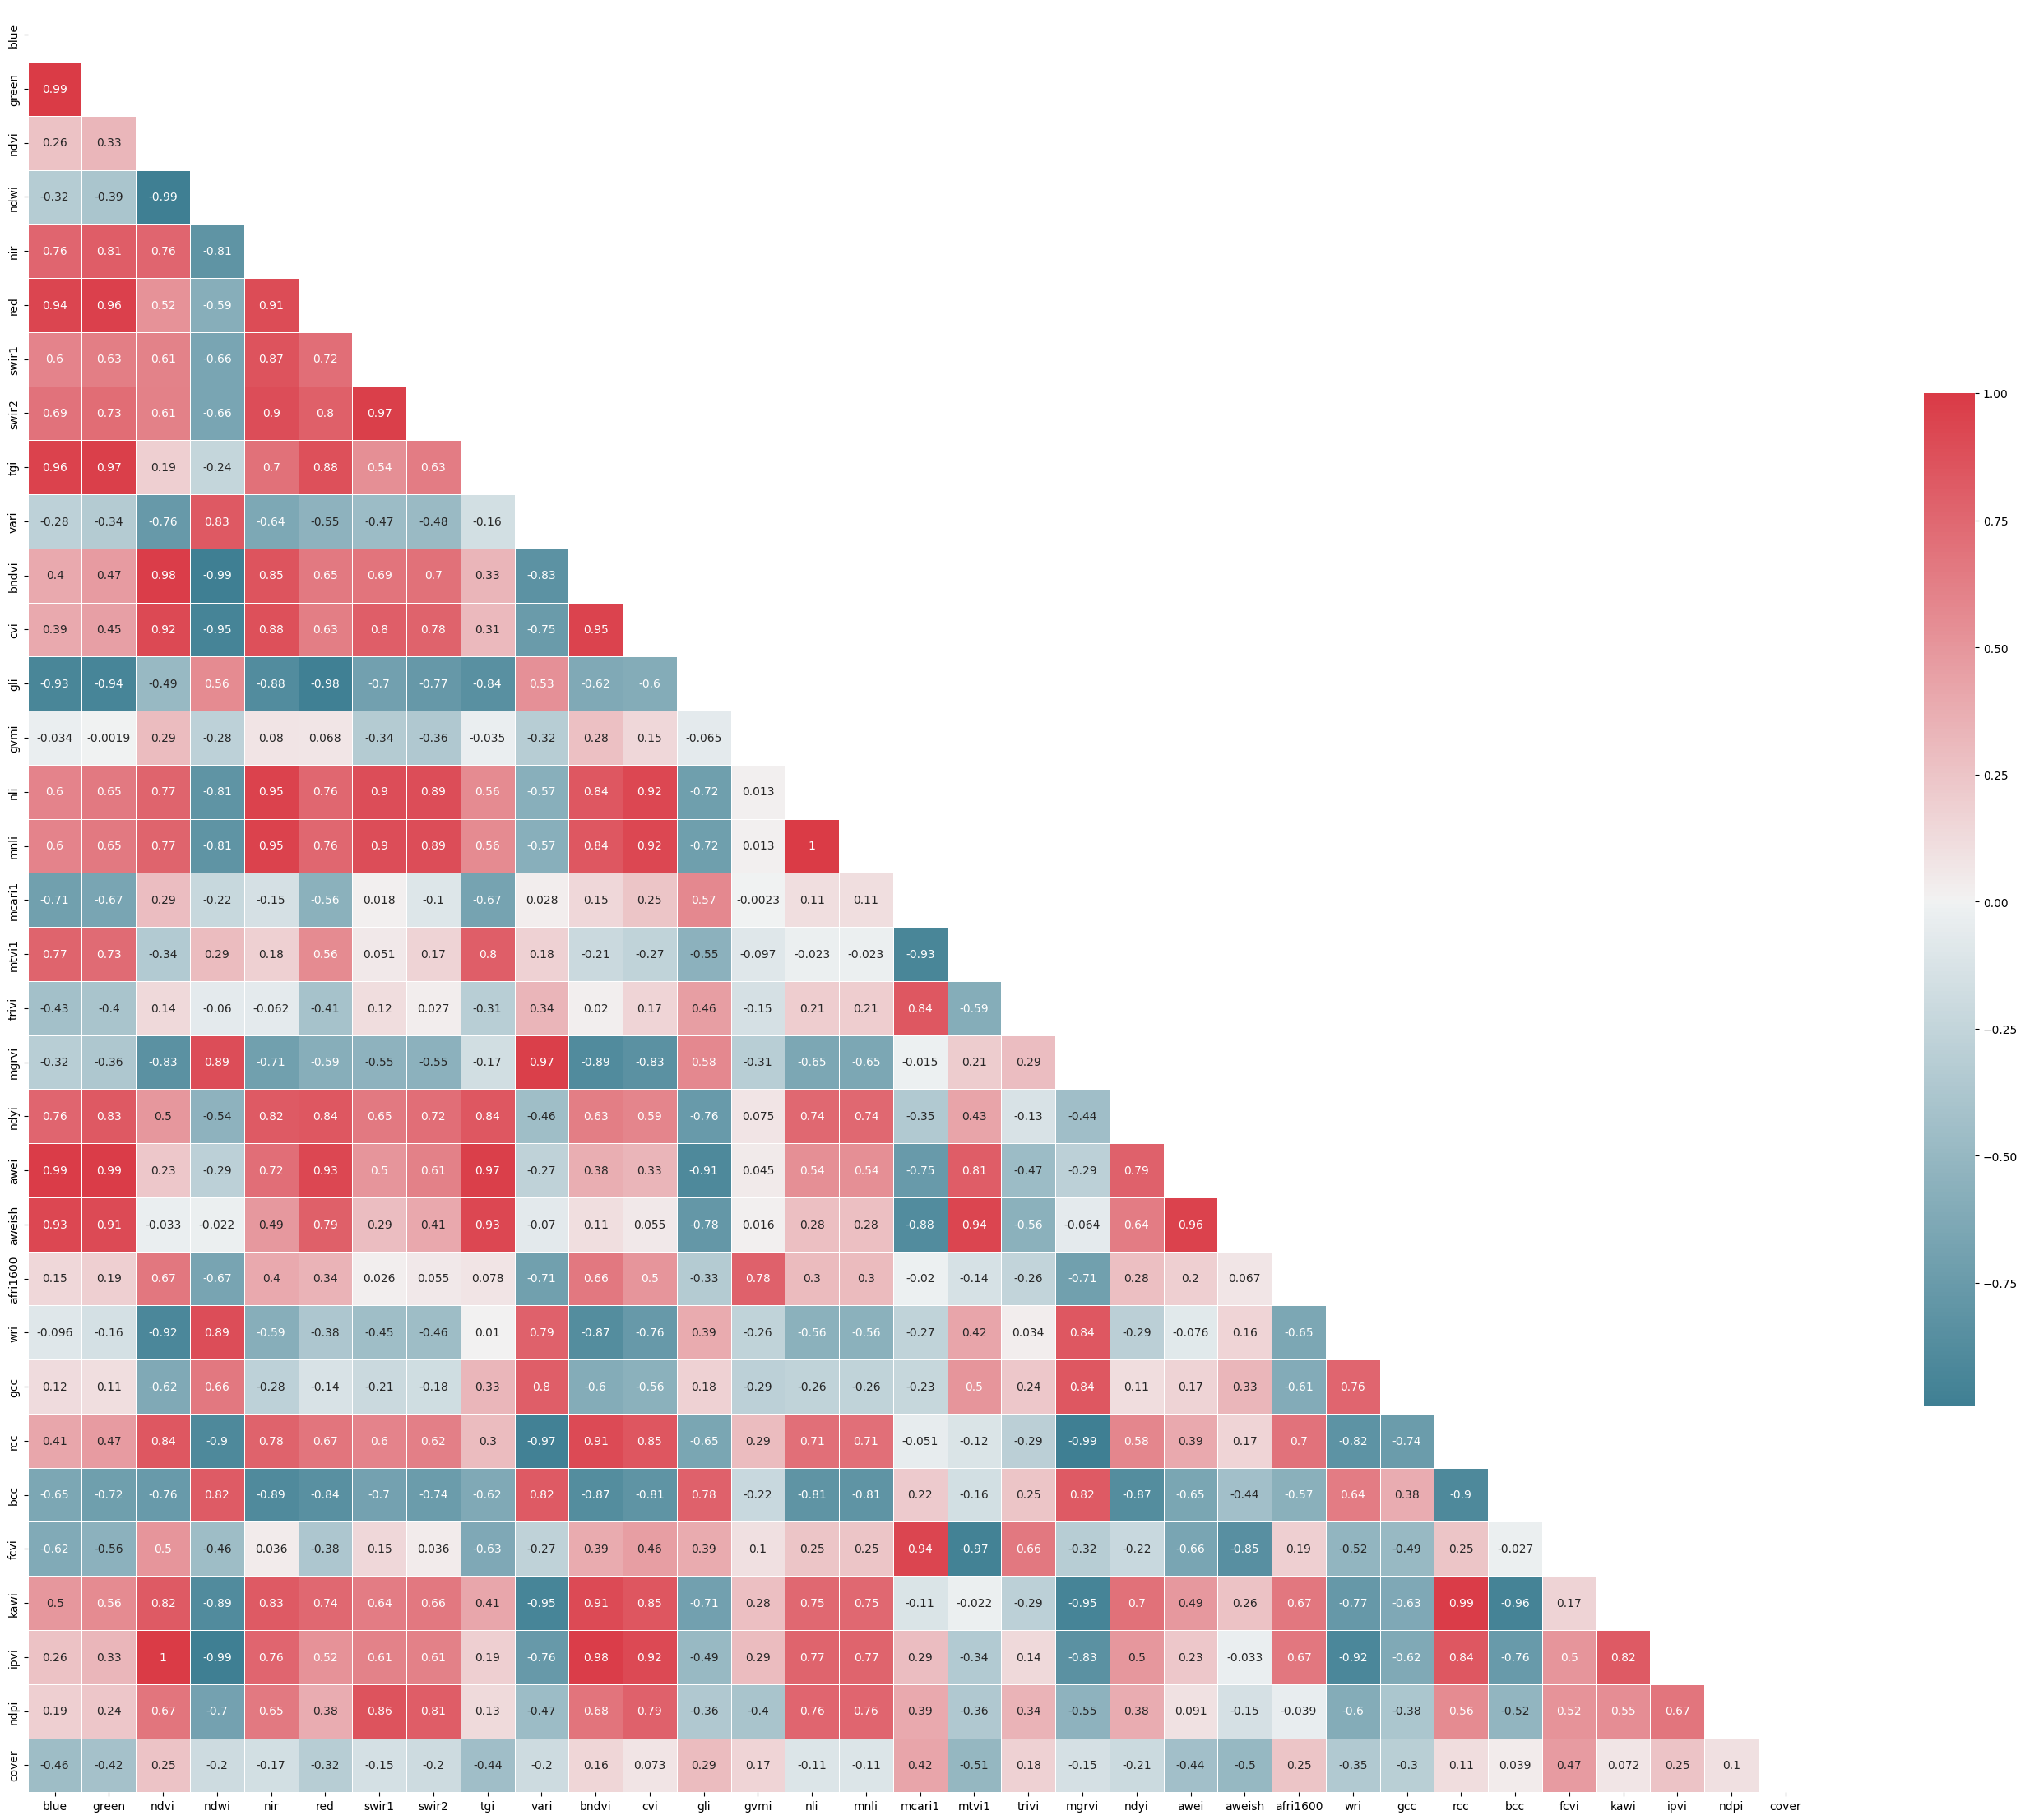

In [ ]:
# Pearson Correlation
pearsoncorr = df.corr(method='pearson')

# Generate a mask for the upper triangle
mask = np.zeros_like(pearsoncorr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(35, 32))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(pearsoncorr, mask=mask, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

In [ ]:
correlation = pearsoncorr.sort_values(by='cover', ascending = False)['cover']
corr = list(correlation.head(11).keys())
correlation.head(11)

,cover
cover,1.000000
fcvi,0.472260
mcari1,0.418564
gli,0.294619
ndvi,0.254315
ipvi,0.254315
afri1600,0.250780
trivi,0.175139
gvmi,0.166253
bndvi,0.155618


In [ ]:
correlation.tail(11)

,cover
vari,-0.199047
ndyi,-0.206659
gcc,-0.302524
red,-0.318603
wri,-0.352792
green,-0.419161
awei,-0.440364
tgi,-0.441664
blue,-0.458866
aweish,-0.495695


### **Regression**
Split dataset into train (70%) and test (30%) for the regression modelling. The train dataset will be used to tune the hyperparameters of the regression algorithm. The test dataset will then be used to validate the model.

In [ ]:
features = list(df.columns)
features.remove('cover')

train, test = train_test_split(df, test_size = 0.30) # Split dataset into Train and Test

x_train, y_train = train[features], train['cover']
x_test, y_test = test[features], test['cover']

# Convert array to dataframe
yTrain = pd.DataFrame(y_train)
yTest  = pd.DataFrame(y_test)

dfTrain = pd.concat([x_train, yTrain], axis=1)
dfTrain

,blue,green,ndvi,ndwi,nir,red,swir1,swir2,tgi,vari,...,afri1600,wri,gcc,rcc,bcc,fcvi,kawi,ipvi,ndpi,cover
1246,0.032600,0.041333,-0.399345,0.543248,0.012233,0.028500,0.004600,0.004183,0.010332,0.344673,...,0.602340,4.148515,0.403514,0.278230,0.318256,-0.021911,-0.067103,0.300327,-0.799710,0.632000
1863,0.096667,0.142000,-0.303642,0.436036,0.055767,0.104400,0.014167,0.012300,0.042317,0.251113,...,0.712823,3.523355,0.413914,0.304314,0.281772,-0.058589,0.038462,0.348179,-0.818570,0.324502
478,0.034500,0.044460,-0.308239,0.465070,0.016233,0.030700,0.004520,0.004050,0.011442,0.338416,...,0.689517,3.621587,0.405435,0.279956,0.314609,-0.020320,-0.058282,0.345881,-0.815435,0.790000
1139,0.032462,0.037900,-0.528542,0.689032,0.006978,0.022623,0.002818,0.002726,0.009275,0.544427,...,0.579080,6.178371,0.407590,0.243297,0.349113,-0.024017,-0.178621,0.235729,-0.861576,0.948000
146,0.036567,0.044433,-0.415677,0.566392,0.012300,0.029800,0.005486,0.004525,0.010506,0.388496,...,0.545171,4.173762,0.401023,0.268953,0.330024,-0.024633,-0.101959,0.292162,-0.780216,0.595000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716,0.065100,0.100800,0.006057,0.072340,0.087200,0.086150,0.027600,0.021150,0.027491,0.120230,...,0.654398,1.628484,0.399921,0.341797,0.258282,0.003183,0.139174,0.503029,-0.570093,0.219230
940,0.034683,0.043500,-0.385921,0.559140,0.012300,0.027760,0.004300,0.004250,0.011517,0.430329,...,0.625050,4.292771,0.410597,0.262027,0.327376,-0.023014,-0.110874,0.307039,-0.820084,0.136000
816,0.044925,0.055967,-0.566278,0.702624,0.009775,0.035300,0.005300,0.005333,0.014795,0.445963,...,0.472915,6.054174,0.410940,0.259194,0.329866,-0.035622,-0.119975,0.216861,-0.826986,0.305000
674,0.029760,0.038000,-0.354187,0.501383,0.012620,0.026462,0.004740,0.004909,0.009526,0.332469,...,0.602702,3.713278,0.403301,0.280851,0.315848,-0.018788,-0.058651,0.322907,-0.778194,0.682000


#### Random Forest Regressor

In [ ]:
rf_grid = {'bootstrap': [True, False],
 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4], # minLeafPopulation
 'min_samples_split': [2, 5, 10], # variablesPerSplit
 'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000] # numberOfTrees
}

# Instantiate RandomizedSearchCV model
rs_model = RandomizedSearchCV(RandomForestRegressor(n_jobs=-1, random_state=42),
                              param_distributions=rf_grid,
                              n_iter=5,
                              cv=5,
                              verbose=True)
# fit
rs_model.fit(x_train, yTrain)

print("Best Hyperparameters for Random Forest Regressor")
rs_model.best_params_

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Hyperparameters for Random Forest Regressor


{'n_estimators': 1000,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 60,
 'bootstrap': False}

In [ ]:
prediction = rs_model.predict(x_test)

In [ ]:
print ("RMSE: ", np.sqrt(mean_squared_error(y_test, prediction)))
print ("R2 Score: ", r2_score(y_test, prediction))

RMSE:  0.14351351848961494
R2 Score:  0.7497594883322729


[Text(0, 0.5, 'Standardized Residuals'),
 Text(0.5, 0, 'Predicted Values for Seagrass Cover')]

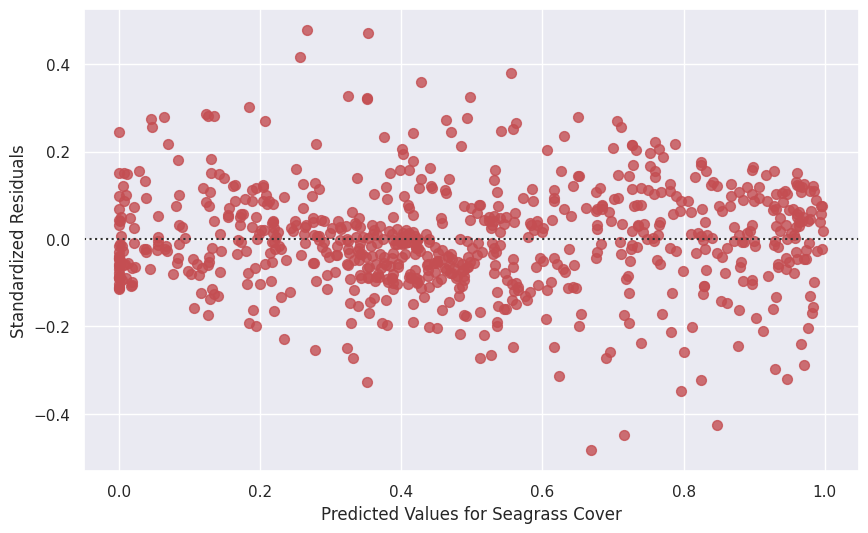

In [ ]:
%matplotlib inline
sns.set(font_scale=1)
fig, ax = plt.subplots(figsize=(10,6))
ax = sns.residplot(x=y_test, y=prediction, scatter_kws={'s':50}, color="r")
ax.set(ylabel='Standardized Residuals', xlabel='Predicted Values for Seagrass Cover')

[Text(0.5, 0, 'True Values'), Text(0, 0.5, 'Predicted Values')]

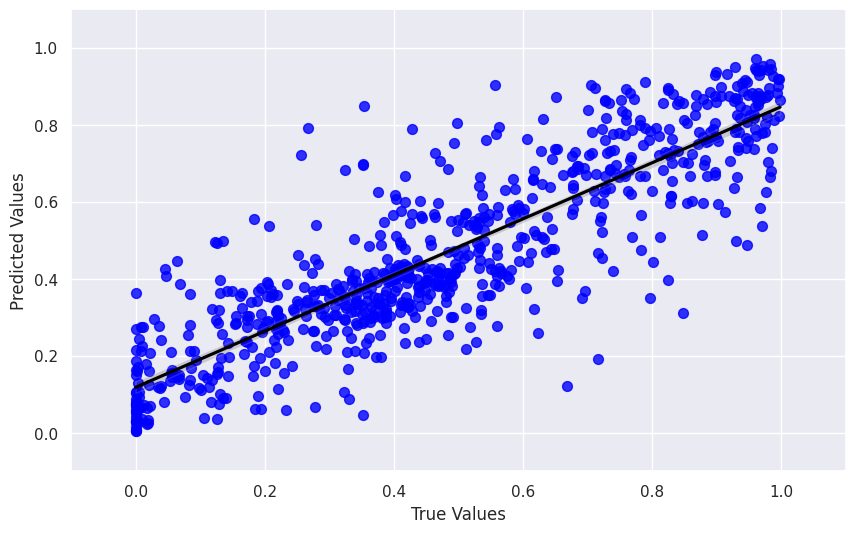

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax = sns.regplot(x=y_test, y=prediction,
            marker='o', color='blue', scatter_kws={'s':50}, line_kws={"color": "black"})
ax.set(xlim = (-0.1, 1.1))
ax.set(ylim = (-0.1, 1.1))
ax.set(xlabel='True Values', ylabel='Predicted Values')

#### TabNet Regressor

In [ ]:
# Split TRAIN into train + validation
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train,
    yTrain,
    test_size=0.20,      # 20% of training data for validation
    random_state=42,
    shuffle=True
)

print(f"Training samples: {x_tr.shape[0]}")
print(f"Validation samples: {x_val.shape[0]}")
print(f"Features: {x_tr.shape[1]}")

Training samples: 1425
Validation samples: 357
Features: 32


In [ ]:
# ============================================================================
# 1. SETUP AND UTILITIES
# ============================================================================

class DirectoryManager:
    """Manages creation of necessary directories"""

    @staticmethod
    def create_directories():
        """Create all required directories if they don't exist"""
        directories = ['checkpoints', 'models', 'results', 'plots']
        for directory in directories:
            Path(directory).mkdir(parents=True, exist_ok=True)
        print("✓ All directories created/verified")


class MetricsCalculator:
    """Calculate various model performance metrics"""

    @staticmethod
    def calculate_rmse(y_true, y_pred):
        """Calculate Root Mean Squared Error"""
        mse = mean_squared_error(y_true, y_pred)
        return np.sqrt(mse)

    @staticmethod
    def calculate_all_metrics(y_true, y_pred):
        """Calculate comprehensive metrics"""
        metrics = {
            'rmse': MetricsCalculator.calculate_rmse(y_true, y_pred),
            'mae': mean_absolute_error(y_true, y_pred),
            'r2': r2_score(y_true, y_pred)
        }

        # Calculate correlation if scipy available
        try:
            from scipy import stats
            correlation, _ = stats.pearsonr(
                y_true.flatten(),
                y_pred.flatten()
            )
            metrics['correlation'] = correlation
        except ImportError:
            metrics['correlation'] = None

        return metrics


class ResultsSaver:
    """Handle saving of models, results, and visualizations"""

    @staticmethod
    def save_model_checkpoint(model, params, fold, metrics, trial_num):
        """Save model checkpoint for a specific fold"""
        checkpoint_path = f"checkpoints/trial_{trial_num}_fold_{fold}_full.pkl"
        try:
            joblib.dump({
                'model': model,
                'params': params,
                'fold': fold,
                'metrics': metrics,
                'history': model.history if hasattr(model, 'history') else None
            }, checkpoint_path)
        except Exception as e:
            print(f"    Warning: Could not save checkpoint: {e}")

    @staticmethod
    def save_best_models(best_models, best_params):
        """Save best models and parameters"""
        try:
            # Save the last fold's model as the main best model
            best_models[-1].save_model("models/best_tabnet_model.zip")

            # Save best parameters
            with open("models/best_parameters.json", "w") as f:
                # Convert optimizer_params to serializable format
                params_to_save = best_params.copy()
                json.dump(params_to_save, f, indent=2, default=str)

            # Save all CV models
            for fold_idx, model in enumerate(best_models, 1):
                model.save_model(f"models/best_cv_fold_{fold_idx}.zip")

            print("    ✓ Best models saved")
        except Exception as e:
            print(f"    Warning: Could not save best models: {e}")

    @staticmethod
    def save_final_artifacts(final_model, x_train, best_params, final_metrics):
        """Save all final model artifacts"""
        try:
            # Save final model
            final_model.save_model("models/final_tabnet_model.zip")

            # Save complete model package
            joblib.dump({
                'model': final_model,
                'features': x_train.columns.tolist(),
                'best_params': best_params,
                'validation_metrics': final_metrics
            }, "models/final_model_full.pkl")

            # Save model weights
            torch.save(
                final_model.network.state_dict(),
                "models/tabnet_weights.pth"
            )

            print("✓ Final model artifacts saved")
        except Exception as e:
            print(f"Warning: Could not save some artifacts: {e}")

    @staticmethod
    def save_feature_importance(model, feature_names):
        """Save and optionally plot feature importance"""
        if not hasattr(model, 'feature_importances_'):
            print("Note: Model does not have feature importance")
            return

        try:
            feature_importance = model.feature_importances_
            importance_df = pd.DataFrame({
                'feature': feature_names,
                'importance': feature_importance
            }).sort_values('importance', ascending=False)

            importance_df.to_csv("results/feature_importance.csv", index=False)

            # Try to plot if matplotlib available
            try:
                import matplotlib.pyplot as plt

                top_n = min(15, len(importance_df))
                top_features = importance_df.head(top_n)

                plt.figure(figsize=(12, 8))
                plt.barh(range(top_n), top_features['importance'].values[::-1])
                plt.yticks(range(top_n), top_features['feature'].values[::-1])
                plt.xlabel('Feature Importance')
                plt.title(f'Top {top_n} Most Important Features')
                plt.tight_layout()
                plt.savefig('plots/feature_importance.png', dpi=100, bbox_inches='tight')
                plt.close()
                print("✓ Feature importance saved and plotted")
            except ImportError:
                print("✓ Feature importance saved (matplotlib not available for plot)")

            return importance_df
        except Exception as e:
            print(f"Warning: Could not save feature importance: {e}")
            return None

    @staticmethod
    def save_training_history(model):
        """Save and optionally plot training history"""
        if not hasattr(model, 'history') or model.history is None:
            print("Note: No training history available")
            return

        try:
            history_df = pd.DataFrame(model.history)
            history_df.to_csv("results/training_history.csv", index=False)

            # Try to plot if matplotlib available
            try:
                import matplotlib.pyplot as plt

                plt.figure(figsize=(12, 5))

                plt.subplot(1, 2, 1)
                plt.plot(history_df['loss'], label='Training Loss')
                plt.xlabel('Epoch')
                plt.ylabel('Loss')
                plt.title('Training Loss')
                plt.legend()
                plt.grid(True, alpha=0.3)

                if 'val_0_rmse' in history_df.columns:
                    plt.subplot(1, 2, 2)
                    plt.plot(history_df['val_0_rmse'], label='Validation RMSE', color='orange')
                    plt.xlabel('Epoch')
                    plt.ylabel('RMSE')
                    plt.title('Validation RMSE')
                    plt.legend()
                    plt.grid(True, alpha=0.3)

                plt.tight_layout()
                plt.savefig('plots/training_history.png', dpi=100, bbox_inches='tight')
                plt.close()
                print("✓ Training history saved and plotted")
            except ImportError:
                print("✓ Training history saved (matplotlib not available for plot)")
        except Exception as e:
            print(f"Warning: Could not save training history: {e}")


# ============================================================================
# 2. TABNET MODEL TRAINER
# ============================================================================

class TabNetTrainer:
    """Handles TabNet model training and evaluation"""

    def __init__(self, params, verbose=0, seed=42):
        self.params = params
        self.verbose = verbose
        self.seed = seed

    def train(self, x_train, y_train, x_val, y_val):
        """Train a TabNet model with given data"""
        model = TabNetRegressor(
            n_d=self.params["n_d"],
            n_a=self.params["n_a"],
            n_steps=self.params["n_steps"],
            gamma=self.params["gamma"],
            lambda_sparse=self.params["lambda_sparse"],
            optimizer_fn=torch.optim.Adam,
            optimizer_params=self.params["optimizer_params"],
            mask_type=self.params["mask_type"],
            verbose=self.verbose,
            seed=self.seed
        )

        model.fit(
            x_train.values,
            y_train.values.reshape(-1, 1),
            eval_set=[(x_val.values, y_val.values.reshape(-1, 1))],
            eval_metric=["rmse"],
            max_epochs=200,
            patience=20,
            batch_size=1024,
            virtual_batch_size=128,
            num_workers=0,
            drop_last=False
        )

        return model

    def evaluate(self, model, x_test, y_test):
        """Evaluate model and return predictions and metrics"""
        predictions = model.predict(x_test.values)
        metrics = MetricsCalculator.calculate_all_metrics(y_test, predictions)
        return predictions, metrics


# ============================================================================
# 3. HYPERPARAMETER SEARCH MANAGER
# ============================================================================

class HyperparameterSearch:
    """Manages hyperparameter search with cross-validation"""

    def __init__(self, param_grid, n_iter=5, cv_folds=3, random_state=42):
        self.param_grid = param_grid
        self.n_iter = n_iter
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.best_score = np.inf
        self.best_params = None
        self.best_models = None
        self.all_results = []

    def run_single_trial(self, trial_num, params, x_train, y_train):
        """Run a single hyperparameter trial with cross-validation"""
        print(f"\n{'='*40}")
        print(f"TRIAL {trial_num}/{self.n_iter}")
        print(f"{'='*40}")
        self._print_params(params)

        trial_start = time.time()
        cv_scores = []
        cv_histories = []
        cv_models = []

        # Cross-validation
        kf = KFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)

        for fold, (train_idx, val_idx) in enumerate(kf.split(x_train), 1):
            fold_start = time.time()

            # Split data
            x_tr_fold = x_train.iloc[train_idx]
            y_tr_fold = y_train.iloc[train_idx]
            x_val_fold = x_train.iloc[val_idx]
            y_val_fold = y_train.iloc[val_idx]

            print(f"\n  Fold {fold}/{self.cv_folds}")
            print(f"  Training: {len(x_tr_fold)}, Validation: {len(x_val_fold)}")

            # Train and evaluate
            trainer = TabNetTrainer(params, verbose=0)
            model = trainer.train(x_tr_fold, y_tr_fold, x_val_fold, y_val_fold)
            _, metrics = trainer.evaluate(model, x_val_fold, y_val_fold)

            cv_scores.append(metrics['rmse'])
            cv_histories.append(model.history if hasattr(model, 'history') else None)
            cv_models.append(model)

            fold_time = time.time() - fold_start
            print(f"  Fold {fold} - RMSE: {metrics['rmse']:.4f}, "
                  f"MAE: {metrics['mae']:.4f}, R²: {metrics['r2']:.4f}, "
                  f"Time: {fold_time:.1f}s")

            # Save checkpoint
            ResultsSaver.save_model_checkpoint(
                model, params, fold, metrics, trial_num
            )

            # Show top features
            self._show_top_features(model, x_train, fold)

        # Calculate CV statistics
        mean_cv_score = np.mean(cv_scores)
        std_cv_score = np.std(cv_scores)
        trial_time = time.time() - trial_start

        print(f"\n  CV Results: Mean RMSE: {mean_cv_score:.4f} (±{std_cv_score:.4f})")
        print(f"  Trial time: {trial_time:.1f}s")

        return {
            'cv_scores': cv_scores,
            'mean_rmse': mean_cv_score,
            'std_rmse': std_cv_score,
            'trial_time': trial_time,
            'cv_histories': cv_histories,
            'cv_models': cv_models
        }

    def run(self, x_train, y_train):
        """Run complete hyperparameter search"""
        print("\n" + "="*60)
        print("HYPERPARAMETER SEARCH")
        print("="*60)
        print(f"Total trials: {self.n_iter}")
        print(f"Cross-validation folds: {self.cv_folds}")

        # Generate parameter combinations
        param_list = list(ParameterSampler(
            self.param_grid,
            n_iter=self.n_iter,
            random_state=self.random_state
        ))

        # Run trials
        for i, params in enumerate(tqdm(param_list, desc="Hyperparameter Search"), 1):
            trial_results = self.run_single_trial(i, params, x_train, y_train)

            # Store results
            trial_result = {
                "trial": i,
                "n_d": params["n_d"],
                "n_a": params["n_a"],
                "n_steps": params["n_steps"],
                "gamma": params["gamma"],
                "lambda_sparse": params["lambda_sparse"],
                "learning_rate": params["optimizer_params"]["lr"],
                "mask_type": params["mask_type"],
                "cv_scores": trial_results['cv_scores'],
                "mean_rmse": trial_results['mean_rmse'],
                "std_rmse": trial_results['std_rmse'],
                "training_time": trial_results['trial_time']
            }
            self.all_results.append(trial_result)

            # Save results periodically
            self._save_intermediate_results()

            # Check if best
            if trial_results['mean_rmse'] < self.best_score:
                self.best_score = trial_results['mean_rmse']
                self.best_params = params.copy()
                self.best_models = trial_results['cv_models'].copy()
                print(f"  🎯 NEW BEST! Mean RMSE: {self.best_score:.4f}")
                ResultsSaver.save_best_models(self.best_models, self.best_params)

        return self.best_params, self.best_score

    def _print_params(self, params):
        """Print parameters in a readable format"""
        print("Parameters:")
        for key, value in params.items():
            if key == "optimizer_params":
                print(f"  {key}: lr={value['lr']}")
            else:
                print(f"  {key}: {value}")

    def _show_top_features(self, model, x_train, fold):
        """Display top features for a fold"""
        if hasattr(model, 'feature_importances_'):
            try:
                feature_importance = model.feature_importances_
                sorted_idx = np.argsort(feature_importance)[::-1]
                top_features = [x_train.columns[idx] for idx in sorted_idx[:3]]
                print(f"  Top 3 features (fold {fold}): {', '.join(top_features)}")
            except:
                pass

    def _save_intermediate_results(self):
        """Save intermediate results"""
        if self.all_results:
            results_df = pd.DataFrame(self.all_results)
            results_df['cv_scores'] = results_df['cv_scores'].apply(str)
            results_df.to_csv("results/hyperparameter_search_results.csv", index=False)


# ============================================================================
# 4. MAIN TRAINING PIPELINE
# ============================================================================

class TabNetPipeline:
    """Complete TabNet training pipeline"""

    def __init__(self, x_train, y_train, x_val, y_val):
        self.x_train = x_train
        self.y_train = y_train
        self.x_val = x_val
        self.y_val = y_val

        # Setup
        DirectoryManager.create_directories()

    def define_hyperparameter_grid(self):
        """Define hyperparameter search space"""
        return {
            "n_d": [8, 16, 24, 32],
            "n_a": [8, 16, 24, 32],
            "n_steps": [3, 4, 5, 6],
            "gamma": [1.0, 1.3, 1.5, 2.0],
            "lambda_sparse": [1e-5, 1e-4, 1e-3],
            "optimizer_params": [
                dict(lr=2e-2),
                dict(lr=1e-2),
                dict(lr=5e-3)
            ],
            "mask_type": ["sparsemax", "entmax"]
        }

    def run_hyperparameter_search(self, n_iter=5, cv_folds=3):
        """Run hyperparameter search"""
        param_grid = self.define_hyperparameter_grid()

        search = HyperparameterSearch(
            param_grid=param_grid,
            n_iter=n_iter,
            cv_folds=cv_folds
        )

        best_params, best_score = search.run(self.x_train, self.y_train)
        return best_params, best_score, search.all_results

    def train_final_model(self, best_params):
        """Train final model on full training data"""
        print("\n" + "="*60)
        print("FINAL MODEL TRAINING")
        print("="*60)

        print(f"\nBest parameters found:")
        for key, value in best_params.items():
            if key == "optimizer_params":
                print(f"  {key}: lr={value['lr']}")
            else:
                print(f"  {key}: {value}")

        # Combine training and validation data
        x_final_train = pd.concat([self.x_train, self.x_val])
        y_final_train = pd.concat([self.y_train, self.y_val])

        print(f"\nFinal training samples: {x_final_train.shape[0]}")

        # Train final model
        final_start = time.time()
        trainer = TabNetTrainer(best_params, verbose=1)
        final_model = trainer.train(
            x_final_train, y_final_train,
            self.x_val, self.y_val
        )
        final_time = time.time() - final_start

        print(f"\nFinal model training completed in {final_time:.1f}s")

        return final_model, final_time

    def evaluate_final_model(self, final_model):
        """Evaluate final model on validation set"""
        print("\n" + "="*60)
        print("FINAL MODEL EVALUATION")
        print("="*60)

        trainer = TabNetTrainer({})
        final_preds, final_metrics = trainer.evaluate(
            final_model, self.x_val, self.y_val
        )

        print(f"\nValidation Set Performance:")
        print(f"  RMSE: {final_metrics['rmse']:.4f}")
        print(f"  MAE:  {final_metrics['mae']:.4f}")
        print(f"  R²:   {final_metrics['r2']:.4f}")
        if final_metrics['correlation'] is not None:
            print(f"  Correlation: {final_metrics['correlation']:.4f}")

        # Error statistics
        errors = self.y_val.values.flatten() - final_preds.flatten()
        print(f"  Mean Error: {np.mean(errors):.4f}")
        print(f"  Std Error: {np.std(errors):.4f}")

        return final_preds, final_metrics, errors

    def save_all_results(self, final_model, best_params, final_metrics,
                        final_preds, errors, all_results, total_time):
        """Save all results and artifacts"""
        print("\n" + "="*60)
        print("SAVING ARTIFACTS")
        print("="*60)

        # Save model artifacts
        ResultsSaver.save_final_artifacts(
            final_model, self.x_train, best_params, final_metrics
        )

        # Save feature importance
        importance_df = ResultsSaver.save_feature_importance(
            final_model, self.x_train.columns
        )

        if importance_df is not None:
            print(f"\nTop 10 most important features:")
            for j, row in importance_df.head(10).iterrows():
                print(f"  {j+1:2d}. {row['feature']:<30} {row['importance']:.4f}")

        # Save training history
        ResultsSaver.save_training_history(final_model)

        # Save predictions
        predictions_df = pd.DataFrame({
            'actual': self.y_val.values.flatten(),
            'predicted': final_preds.flatten(),
            'error': errors
        })
        predictions_df.to_csv("results/predictions.csv", index=False)
        print("✓ Predictions saved")

        # Save comprehensive results
        if all_results:
            results_df = pd.DataFrame(all_results)
            results_df['cv_scores'] = results_df['cv_scores'].apply(str)
            results_df.to_csv("results/comprehensive_results.csv", index=False)
            print("✓ Comprehensive results saved")

        # Save training summary
        summary = {
            "best_parameters": {
                "n_d": best_params["n_d"],
                "n_a": best_params["n_a"],
                "n_steps": best_params["n_steps"],
                "gamma": best_params["gamma"],
                "lambda_sparse": best_params["lambda_sparse"],
                "learning_rate": best_params["optimizer_params"]["lr"],
                "mask_type": best_params["mask_type"]
            },
            "final_validation_metrics": {
                "rmse": float(final_metrics['rmse']),
                "mae": float(final_metrics['mae']),
                "r2": float(final_metrics['r2']),
                "correlation": float(final_metrics['correlation']) if final_metrics['correlation'] else None
            },
            "training_details": {
                "n_trials": len(all_results),
                "total_training_time": float(total_time),
                "final_training_samples": int(len(self.x_train) + len(self.x_val)),
                "n_features": int(self.x_train.shape[1])
            }
        }

        with open("results/training_summary.json", "w") as f:
            json.dump(summary, f, indent=2)
        print("✓ Training summary saved")

    def run_complete_pipeline(self, n_iter=5, cv_folds=3):
        """Run the complete training pipeline"""
        print("\n" + "="*60)
        print("TABNET TRAINING PIPELINE")
        print("="*60)

        pipeline_start = time.time()

        # 1. Hyperparameter search
        best_params, best_score, all_results = self.run_hyperparameter_search(
            n_iter=n_iter, cv_folds=cv_folds
        )

        # 2. Train final model
        final_model, final_time = self.train_final_model(best_params)

        # 3. Evaluate final model
        final_preds, final_metrics, errors = self.evaluate_final_model(final_model)

        # 4. Save all results
        total_time = time.time() - pipeline_start
        self.save_all_results(
            final_model, best_params, final_metrics,
            final_preds, errors, all_results, total_time
        )

        # Final summary
        print("\n" + "="*60)
        print("PIPELINE COMPLETE!")
        print("="*60)
        print(f"\nResults Summary:")
        print(f"  Best CV RMSE: {best_score:.4f}")
        print(f"  Final Validation RMSE: {final_metrics['rmse']:.4f}")
        print(f"  Final Validation R²: {final_metrics['r2']:.4f}")
        print(f"  Total pipeline time: {total_time:.1f}s")
        print(f"\nAll artifacts saved in 'models/', 'results/', and 'plots/' directories")
        print("="*60)

        return final_model, best_params, final_metrics


# ============================================================================
# 5. USAGE EXAMPLE
# ============================================================================

if __name__ == "__main__":
    # Assuming you have x_tr, y_tr, x_val, y_val defined
    # Example:
    pipeline = TabNetPipeline(x_tr, y_tr, x_val, y_val)
    final_model, best_params, final_metrics = pipeline.run_complete_pipeline(
         n_iter=5,
        cv_folds=3
    )

    print("TabNet Pipeline module loaded successfully!")
    print("Usage:")
    print("  pipeline = TabNetPipeline(x_train, y_train, x_val, y_val)")
    print("  final_model, best_params, metrics = pipeline.run_complete_pipeline()")

✓ All directories created/verified

TABNET TRAINING PIPELINE

HYPERPARAMETER SEARCH
Total trials: 5
Cross-validation folds: 3


Hyperparameter Search:   0%|          | 0/5 [00:00<?, ?it/s]


TRIAL 1/5
Parameters:
  optimizer_params: lr=0.005
  n_steps: 5
  n_d: 32
  n_a: 16
  mask_type: sparsemax
  lambda_sparse: 0.001
  gamma: 1.0

  Fold 1/3
  Training: 950, Validation: 475


Hyperparameter Search:   0%|          | 0/5 [00:04<?, ?it/s]


Early stopping occurred at epoch 33 with best_epoch = 13 and best_val_0_rmse = 0.29059


AttributeError: 'DataFrame' object has no attribute 'flatten'

DATA PREPARATION
Training samples: 1425
Validation samples: 357
Features: 32

RANDOM FOREST HYPERPARAMETER OPTIMIZATION
Starting Random Forest hyperparameter search...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Random Forest Results:
Best Hyperparameters: {'n_estimators': 1000, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 70, 'bootstrap': False}
Best CV Score (Negative MSE): -0.0229
Validation RMSE: 0.1437
Validation MAE: 0.1070
Validation R²: 0.7706
Training Time: 59.8s

XGBOOST HYPERPARAMETER OPTIMIZATION
Starting XGBoost hyperparameter search...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

XGBoost Results:
Best Hyperparameters: {'colsample_bylevel': np.float64(0.5610191174223894), 'colsample_bytree': np.float64(0.7475884550556351), 'gamma': np.float64(0.17194260557609198), 'learning_rate': np.float64(0.28279612062363463), 'max_delta_step': 3, 'max_depth': 4, 'min_child_weight': 8, 'n_estimators': 487, 'reg_alp

ValueError: 
All the 15 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/tmp/ipython-input-4016969113.py", line 206, in fit
    early_stopping = callbacks.EarlyStopping(
                     ^^^^^^^^^
NameError: name 'callbacks' is not defined. Did you mean: 'Callback'?
